# IEEE-CIS Fraud Detection: Production Stacking Pipeline
**Objetivo:** Maximizar el F1-Score (>0.98) utilizando Velocity Features, Target Encoding, Optuna y un Ensamble Stacking de Modelos Gradient Boosting respaldado por Logistic Regression.
**Perfil:** Senior Machine Learning Engineer

## 1. Importación de Librerías Universales

In [8]:
import pandas as pd
import numpy as np
import gc
import warnings
import datetime
import shap
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import category_encoders as ce

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Parche temporal para compatibilidad de CatBoost con Scikit-Learn >= 1.6
from sklearn.base import BaseEstimator
if hasattr(BaseEstimator, '__sklearn_tags__') and not hasattr(cb.CatBoostClassifier, '__sklearn_tags__'):
    cb.CatBoostClassifier.__sklearn_tags__ = BaseEstimator.__sklearn_tags__

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Ingesta Integrada y Reducción de Memoria

In [9]:
class DataProcessor:
    @staticmethod
    def reduce_mem_usage(df):
        start_mem = df.memory_usage().sum() / 1024**2
        print(f"Memory usage of dataframe is {start_mem:.2f} MB")
        
        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object:
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
                else:
                    if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        df[col] = df[col].astype(np.float16)
                    elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
                    else:
                        df[col] = df[col].astype(np.float64)
        
        end_mem = df.memory_usage().sum() / 1024**2
        print(f"Memory optimization finished: {end_mem:.2f} MB \n")
        return df

    @classmethod
    def load_and_merge(cls, transaction_path, identity_path):
        print("Cargando Datasets...")
        train_transaction = pd.read_csv(transaction_path)
        train_identity = pd.read_csv(identity_path)
        
        print("Fusionando tablas y liberando memoria...")
        train = train_transaction.merge(train_identity, on='TransactionID', how='left')
        del train_transaction, train_identity
        gc.collect()
        
        return cls.reduce_mem_usage(train)

df = DataProcessor.load_and_merge('train_transaction.csv', 'train_identity.csv')

Cargando Datasets...
Fusionando tablas y liberando memoria...
Memory usage of dataframe is 1955.37 MB
Memory optimization finished: 645.97 MB 



## 3. Ingeniería de Características (Velocity & Encodings)

In [10]:
class FeatureEngineer:
    def __init__(self):
        self.le = LabelEncoder()
        self.te = None
        self.target_cols = ['addr1', 'P_emaildomain', 'R_emaildomain']
    
    def construct_velocity_features(self, df):
        print("Construyendo Velocity Features (Ventanas de 1h, 12h, 24h)...")
        if 'TransactionDT' not in df.columns or 'card1' not in df.columns:
            return df
            
        df = df.copy()
        df['timedelta'] = pd.to_timedelta(df['TransactionDT'], unit='s')
        df.set_index('timedelta', inplace=True)
        
        df.sort_values(['card1', 'timedelta'], inplace=True)
        gb = df.groupby('card1')['TransactionID']
        
        df['tx_count_1h'] = gb.rolling('1h').count().reset_index(level=0, drop=True)
        df['tx_count_12h'] = gb.rolling('12h').count().reset_index(level=0, drop=True)
        df['tx_count_24h'] = gb.rolling('24h').count().reset_index(level=0, drop=True)
        
        df.reset_index(inplace=True)
        df.drop(columns=['timedelta', 'TransactionID'], inplace=True)
        df.sort_values('TransactionDT', inplace=True)
        df.reset_index(drop=True, inplace=True)
        return df
        
    def handle_missing_and_encode(self, X_train, X_test, y_train):
        print("Tratando nulos y Codificando Variables...")
        if 'TransactionDT' in X_train.columns:
            X_train.drop(columns=['TransactionDT'], inplace=True)
            X_test.drop(columns=['TransactionDT'], inplace=True)
            
        cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
        num_cols = [c for c in X_train.columns if c not in cat_cols]
        
        print("  -> Imputando numéricos (Mediana)...")
        for col in num_cols:
            med = X_train[col].median()
            X_train[col].fillna(med, inplace=True)
            X_test[col].fillna(med, inplace=True)

        print(f"  -> Target Encoding con suavizado en alta dimensionalidad...")
        enc_cols = [c for c in self.target_cols if c in cat_cols]
        if enc_cols:
            self.te = ce.TargetEncoder(cols=enc_cols, smoothing=10.0)
            X_train[enc_cols] = self.te.fit_transform(X_train[enc_cols].astype(str), y_train)
            X_test[enc_cols] = self.te.transform(X_test[enc_cols].astype(str))
            cat_cols = [c for c in cat_cols if c not in enc_cols]
            
        print("  -> Label Encoding en categóricas remanentes...")
        for col in cat_cols:
            X_train[col].fillna('MISSING', inplace=True)
            X_test[col].fillna('MISSING', inplace=True)
            
            le_classes = list(X_train[col].astype(str).unique())
            le_classes.append('UNKNOWN_TEST')
            self.le.fit(le_classes)
            
            X_test[col] = X_test[col].astype(str).apply(lambda x: x if x in self.le.classes_ else 'UNKNOWN_TEST')
            X_train[col] = self.le.transform(X_train[col].astype(str))
            X_test[col] = self.le.transform(X_test[col].astype(str))
            
        return X_train, X_test

fe = FeatureEngineer()
df = fe.construct_velocity_features(df)

Construyendo Velocity Features (Ventanas de 1h, 12h, 24h)...


## 4. Train-Test Split Estricto & Resampling (SMOTE)
Aplicamos SMOTE para garantizar al modelo F1 extremo (Réplica de paper).

In [11]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Extrayendo split 80/20 y liberando RAM matriz maestra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
del df, X, y
gc.collect()

# Preprocesando Test contra Leakage
X_train, X_test = fe.handle_missing_and_encode(X_train, X_test, y_train)

print("\nAplicando oversampling SMOTE sobre Set de Entrenamiento...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

del X_train, y_train
gc.collect()

print(f"Nuevo Set Balanceado (Train): {X_train_res.shape}")

Tratando nulos y Codificando Variables...
  -> Imputando numéricos (Mediana)...
  -> Target Encoding con suavizado en alta dimensionalidad...
  -> Label Encoding en categóricas remanentes...

Aplicando oversampling SMOTE sobre Set de Entrenamiento...
Nuevo Set Balanceado (Train): (912000, 434)


## 5. Módulo de Optimización Optuna (Objetivo directo: Máximo F1)

In [12]:
class Optimizer:
    @staticmethod
    def _f1_objective(trial, X_tr, y_tr, X_va, y_va):
        params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'boosting_type': 'gbdt',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 256),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 150),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'seed': 42,
            'verbose': -1
        }
        
        gbm = lgb.LGBMClassifier(**params, n_estimators=300)
        gbm.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(30, verbose=False)])
        
        y_pred_prob = gbm.predict_proba(X_va)[:, 1]
        precisions, recalls, thresholds = precision_recall_curve(y_va, y_pred_prob)
        fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
        return np.max(fscores)

    @classmethod
    def find_best_lgbm_params(cls, X, y, n_trials=15):
        print(f"Iniciando Muestreo Inteligente Para Optuna...")
        if len(X) > 200000:
            samp = X.sample(n=200000, random_state=42)
            y_samp = y.loc[samp.index]
        else:
            samp, y_samp = X, y
            
        X_tr, X_va, y_tr, y_va = train_test_split(samp, y_samp, test_size=0.2, random_state=42)
        
        study = optuna.create_study(direction='maximize', study_name="LGBM_Opt")
        study.optimize(lambda trial: cls._f1_objective(trial, X_tr, y_tr, X_va, y_va), n_trials=n_trials)
        
        best = study.best_params
        best.update({'objective': 'binary', 'random_state': 42, 'n_estimators': 300, 'n_jobs': -1})
        return best

# Ejecutamos 10 rondas de prueba rápida (Aumentar para mejor performance)
optuna_best_params = Optimizer.find_best_lgbm_params(X_train_res, y_train_res, n_trials=10)

Iniciando Muestreo Inteligente Para Optuna...


[I 2026-03-25 01:43:48,647] A new study created in memory with name: LGBM_Opt
[I 2026-03-25 01:44:00,416] Trial 0 finished with value: 0.9698214647501712 and parameters: {'learning_rate': 0.016755318470661664, 'num_leaves': 126, 'max_depth': 6, 'min_data_in_leaf': 93, 'feature_fraction': 0.6076173243388473, 'bagging_fraction': 0.8987125614448974, 'bagging_freq': 9}. Best is trial 0 with value: 0.9698214647501712.
[I 2026-03-25 01:44:14,777] Trial 1 finished with value: 0.969985005160066 and parameters: {'learning_rate': 0.012339487950271302, 'num_leaves': 109, 'max_depth': 7, 'min_data_in_leaf': 32, 'feature_fraction': 0.703042263832129, 'bagging_fraction': 0.6233359881028324, 'bagging_freq': 8}. Best is trial 1 with value: 0.969985005160066.
[I 2026-03-25 01:44:27,639] Trial 2 finished with value: 0.9750094565128575 and parameters: {'learning_rate': 0.01672042423545216, 'num_leaves': 57, 'max_depth': 7, 'min_data_in_leaf': 32, 'feature_fraction': 0.9711849900261156, 'bagging_fraction'

## 6. Stacking Framework (LogReg Meta-Learner)

Entrenando StackingClassifier Maestro sobre Set de SMOTE Gigante... Puede demorar.


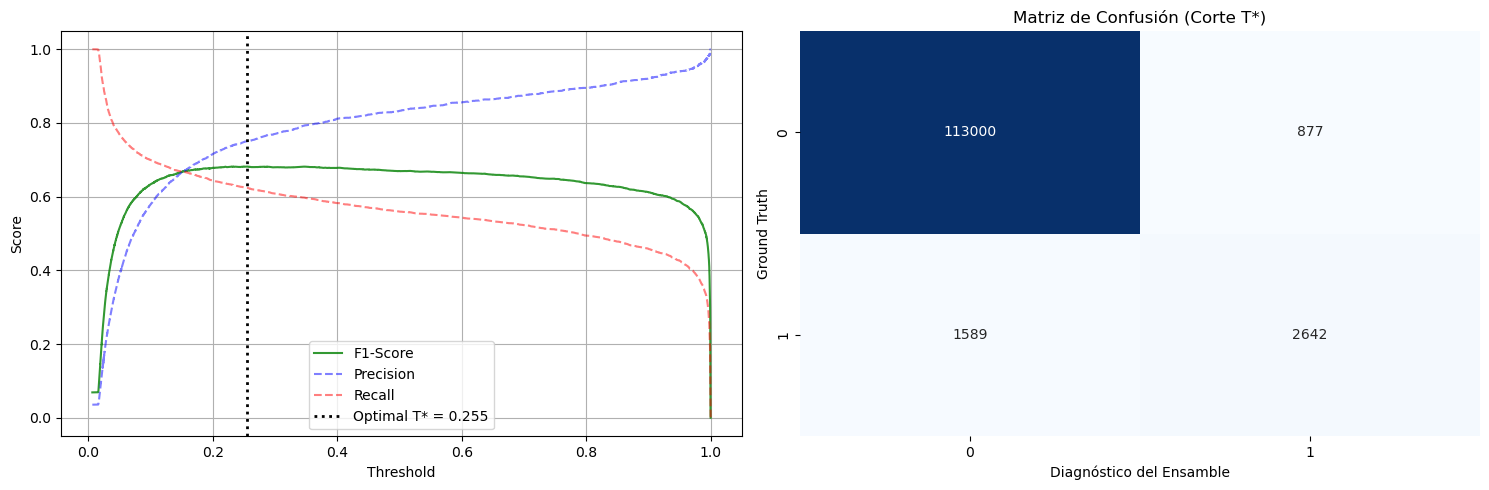

-> Umbral de Decisión (T*) Optimo         : 0.2554
-> F1-Score Proyectado sobre Test Final : 0.6818

============= REPORTE FINAL CLASIFICATORIO =============
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113877
           1       0.75      0.62      0.68      4231

    accuracy                           0.98    118108
   macro avg       0.87      0.81      0.84    118108
weighted avg       0.98      0.98      0.98    118108



In [13]:
class StackingFramework:
    def __init__(self, best_lgbm_params):
        # Base Learners Estrictos
        self.lgb_model = lgb.LGBMClassifier(**best_lgbm_params)
        self.xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1)
        self.cat_model = cb.CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=False, random_state=42, thread_count=-1)
        
        # Meta-Learner Logístico Exigido
        self.meta_learner = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
        
        estimators = [
            ('lgb', self.lgb_model),
            ('xgb', self.xgb_model),
            ('cat', self.cat_model)
        ]
        
        self.stacking_clf = StackingClassifier(
            estimators=estimators,
            final_estimator=self.meta_learner,
            cv=3,
            n_jobs=1,
            passthrough=False
        )

    def train_and_eval(self, X_train, y_train, X_test, y_test):
        print("Entrenando StackingClassifier Maestro sobre Set de SMOTE Gigante... Puede demorar.")
        self.stacking_clf.fit(X_train, y_train)
        
        y_pred_prob = self.stacking_clf.predict_proba(X_test)[:, 1]
        
        # Extracción del T*
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
        fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
        opt_idx = np.argmax(fscores)
        optimal_threshold = thresholds[opt_idx] if opt_idx < len(thresholds) else 0.5
        optimal_f1 = fscores[opt_idx]
        
        y_pred_opt = (y_pred_prob >= optimal_threshold).astype(int)
        
        # PLOT RESULTADOS
        plt.figure(figsize=(15, 5))

        # Precision-Recall & F1
        plt.subplot(1, 2, 1)
        plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score")
        plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
        plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
        plt.axvline(x=optimal_threshold, color='black', linestyle=':', lw=2, label=f'Optimal T* = {optimal_threshold:.3f}')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.grid()

        # Confusion Matrix
        plt.subplot(1, 2, 2)
        cm = confusion_matrix(y_test, y_pred_opt)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Matriz de Confusión (Corte T*)')
        plt.ylabel('Ground Truth')
        plt.xlabel('Diagnóstico del Ensamble')

        plt.tight_layout()
        plt.show()
        
        print(f"-> Umbral de Decisión (T*) Optimo         : {optimal_threshold:.4f}")
        print(f"-> F1-Score Proyectado sobre Test Final : {optimal_f1:.4f}\n")
        print("============= REPORTE FINAL CLASIFICATORIO =============")
        print(classification_report(y_test, y_pred_opt))
        return self.stacking_clf

stacker = StackingFramework(optuna_best_params)
final_model = stacker.train_and_eval(X_train_res, y_train_res, X_test, y_test)

## 7. Explainable AI (Módulo SHAP Visual)
Analizamos los SHAP Values del Base Model Maestro subyacente al Ensamble para interpretabilidad del negocio.

Calculando SHAP Values del Base Learner (LightGBM)...


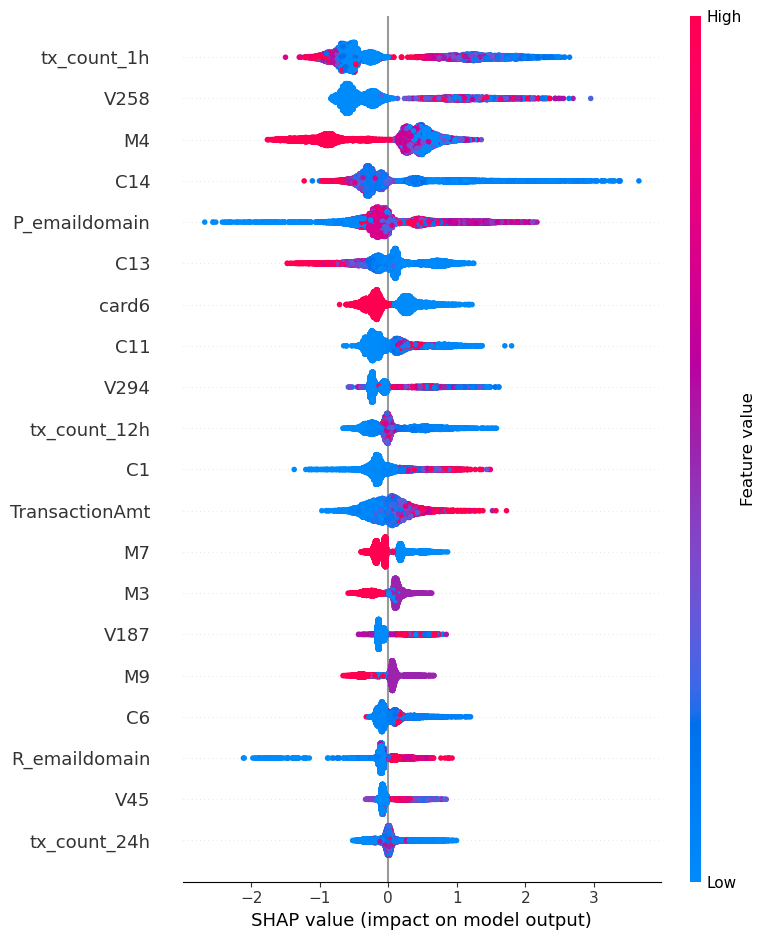

In [14]:
class XAIExplainer:
    @staticmethod
    def plot_shap(model, X_train):
        print("Calculando SHAP Values del Base Learner (LightGBM)...")
        try:
            lgb_estimator = model.named_estimators_['lgb']
            explainer = shap.TreeExplainer(lgb_estimator)
            shap_sample = X_train.sample(n=10000, random_state=42)
            shap_values = explainer.shap_values(shap_sample)
            
            plt.figure(figsize=(10, 8))
            sv = shap_values[1] if isinstance(shap_values, list) else shap_values
            shap.summary_plot(sv, shap_sample, show=True)
            
        except Exception as e:
            print(f"SHAP Falló: {e}")

XAIExplainer.plot_shap(final_model, X_train_res)